In [1]:
import matplotlib.pyplot as plt

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "xtick.major.size": 1.75,
    "ytick.major.size": 1.75,
    "xtick.minor.size": 1.0,
    "ytick.minor.size": 1.0,
    "legend.fontsize": 5,
    "axes.linewidth": 0.5,
})


In [2]:
%load_ext autoreload
%autoreload 2

import sys
import os

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)

from utils.spike_detection import *
from utils.preprocess_neural import *

import matplotlib.pyplot as plt
import matplotlib.cm as cm

import numpy.ma as ma
from scipy.ndimage import gaussian_filter
from tqdm import tqdm
import subprocess
import shutil
import pickle

%matplotlib widget

In [3]:
main_data_folder = '../data/CKII_pAce47_PX_20260128'
FOV_image_folder = '/Volumes/QixinT9/AdamLab/Data/Freely_moving_raw_data/pAce47_PX_2026_01_28'




In [4]:
# # This is how you load the data later

# merged_data_path_CS = os.path.join(main_data_folder, 'merged_aligned_data_CS.pkl')
# with open(merged_data_path_CS, 'rb') as f:
#     loaded_merged_data_CS = pickle.load(f)
#     traces = loaded_merged_data_CS['traces']
#     spikes = loaded_merged_data_CS['spikes']
#     speed = loaded_merged_data_CS['speed']
#     ts_neural = loaded_merged_data_CS['ts_neural']
#     x_neural = loaded_merged_data_CS['x_neural']
#     y_neural = loaded_merged_data_CS['y_neural']
#     hd_angles_neural = loaded_merged_data_CS['hd_angles_neural']
#     weights_all = loaded_merged_data_CS['weights_all']
#     ROIs_all = loaded_merged_data_CS['ROIs_all']
#     mean_images = loaded_merged_data_CS['mean_images']
#     mean_images_raw = loaded_merged_data_CS['mean_images_raw']
#     frame_rate = loaded_merged_data_CS['frame_rate']
#     frame_width = loaded_merged_data_CS['frame_width']
#     frame_height = loaded_merged_data_CS['frame_height']
#     subfolders = loaded_merged_data_CS['subfolders']
#     complex_bursts_dicts = loaded_merged_data_CS['complex_bursts_dicts']
#     refined_SS = loaded_merged_data_CS['refined_SS']
#     all_CS_spikes = loaded_merged_data_CS['all_CS_spikes']
#     all_spikes = loaded_merged_data_CS['all_spikes']
#     spike_heights_interpolated = loaded_merged_data_CS['spike_heights_interpolated']
#     SNR_interpolated = loaded_merged_data_CS['SNR_interpolated']    
#     traces_SNR_interpolated = loaded_merged_data_CS['traces_SNR_interpolated']
#     Vm_SNR_interpolated = loaded_merged_data_CS['Vm_SNR_interpolated']
#     # CS_detection_params = loaded_merged_data_CS['CS_detection_params']
#     # pnorm_CS = CS_detection_params['pnorm_CS']
#     # pnorm_SS = CS_detection_params['pnorm_SS']
#     # process_window_CS = CS_detection_params['process_window_CS']
#     # process_window_SS = CS_detection_params['process_window_SS']
#     # complex_spike_threshold = CS_detection_params['complex_spike_threshold']
# print(f"Loaded data from {merged_data_path_CS}")
# Vms = Vm_SNR_interpolated
# traces = np.array(traces_SNR_interpolated)
# frame_rate = frame_rate

In [5]:
# # Optional: Remove bad SNR segments
# spikes = all_spikes.copy()
# #traces = traces_SNR_interpolated
# #Vms = Vm_SNR_interpolated

# SNR_threshold = 3.5
# bad_masks = []

# # Now for each cell: remove spikes and make traces and Vms NaN where its SNR_interpolated < SNR_threshold
# for cell_idx in range(len(spikes)):
#     snr_vals = np.asarray(SNR_interpolated[cell_idx])
#     if snr_vals.ndim == 0:
#         continue
#     bad_mask = snr_vals < SNR_threshold
#     bad_masks.append(bad_mask)
#     if not np.any(bad_mask):
#         continue

#     #traces[cell_idx][bad_mask] = np.nan
#     #Vms[cell_idx][bad_mask] = np.nan

#     def _filter_spikes(spk_arr, bad_mask_local):
#         spk_arr = np.asarray(spk_arr, dtype=np.int64)
#         if spk_arr.size == 0:
#             return spk_arr
#         spk_arr = spk_arr[(spk_arr >= 0) & (spk_arr < bad_mask_local.shape[0])]
#         return spk_arr[~bad_mask_local[spk_arr]]

#     spikes[cell_idx] = _filter_spikes(spikes[cell_idx], bad_mask)
#     all_CS_spikes[cell_idx] = _filter_spikes(all_CS_spikes[cell_idx], bad_mask)
#     refined_SS[cell_idx] = _filter_spikes(refined_SS[cell_idx], bad_mask)

#     print(f'Cell {cell_idx}: removed {np.sum(bad_mask)} bad SNR frames, spikes reduced from {len(loaded_merged_data_CS["all_spikes"][cell_idx])} to {len(spikes[cell_idx])}')

# bad_masks = np.array(bad_masks)

In [6]:
# load merged data 

merged_data_path_CS = os.path.join(main_data_folder, 'merged_aligned_data.pkl')
with open(merged_data_path_CS, 'rb') as f:
    loaded_merged_data_CS = pickle.load(f)
    traces = loaded_merged_data_CS['traces']
    spikes = loaded_merged_data_CS['spikes']
    speed = loaded_merged_data_CS['speed']
    ts_neural = loaded_merged_data_CS['ts_neural']
    x_neural = loaded_merged_data_CS['x_neural']
    y_neural = loaded_merged_data_CS['y_neural']
    hd_angles_neural = loaded_merged_data_CS['hd_angles_neural']
    frame_rate = loaded_merged_data_CS['frame_rate']
    frame_width = loaded_merged_data_CS['frame_width']
    frame_height = loaded_merged_data_CS['frame_height']
    subfolders = loaded_merged_data_CS['subfolders']
    complex_bursts_dicts = loaded_merged_data_CS['complex_bursts_dicts']
    refined_SS = loaded_merged_data_CS['refined_SS']
    all_CS_spikes = loaded_merged_data_CS['all_CS_spikes']
    all_spikes = loaded_merged_data_CS['all_spikes']
    spike_heights_interpolated = loaded_merged_data_CS['spike_heights_interpolated']
    SNR_interpolated = loaded_merged_data_CS['SNR_interpolated']    
    session_start_frames = loaded_merged_data_CS['session_start_frames']
    traces_SNR_interpolated = loaded_merged_data_CS['traces_SNR_interpolated']
    Vm_SNR_interpolated = loaded_merged_data_CS['Vm_SNR_interpolated']
    burst_metrics = loaded_merged_data_CS['burst_metrics']
    plateaus_dicts = loaded_merged_data_CS.get('plateaus_dicts', None)

    weights_all = loaded_merged_data_CS['weights_all']
    ROIs_all = loaded_merged_data_CS['ROIs_all']
    mean_images = loaded_merged_data_CS['mean_images']
    mean_images_raw = loaded_merged_data_CS['mean_images_raw']
    frame_rate = loaded_merged_data_CS['frame_rate']
    frame_width = loaded_merged_data_CS['frame_width']
    frame_height = loaded_merged_data_CS['frame_height']

print(f"Loaded data from {merged_data_path_CS}")
if plateaus_dicts is not None:
    print(f"Loaded plateaus_dicts for {len(plateaus_dicts)} cells")
else:
    print("No plateaus_dicts found in merged data")


sampling_rate = frame_rate


Loaded data from ../data/CKII_pAce47_PX_20260128/merged_aligned_data.pkl
Loaded plateaus_dicts for 5 cells


In [7]:
# Optional: Remove bad SNR segments
spikes = all_spikes.copy()
#traces = traces_SNR_interpolated
#Vms = Vm_SNR_interpolated

SNR_threshold = 3.5
bad_masks = []

# Now for each cell: remove spikes and make traces and Vms NaN where its SNR_interpolated < SNR_threshold
for cell_idx in range(len(spikes)):
    snr_vals = np.asarray(SNR_interpolated[cell_idx])
    if snr_vals.ndim == 0:
        continue
    bad_mask = snr_vals < SNR_threshold
    bad_masks.append(bad_mask)
    if not np.any(bad_mask):
        continue

    #traces[cell_idx][bad_mask] = np.nan
    #Vms[cell_idx][bad_mask] = np.nan

    def _filter_spikes(spk_arr, bad_mask_local):
        spk_arr = np.asarray(spk_arr, dtype=np.int64)
        if spk_arr.size == 0:
            return spk_arr
        spk_arr = spk_arr[(spk_arr >= 0) & (spk_arr < bad_mask_local.shape[0])]
        return spk_arr[~bad_mask_local[spk_arr]]

    spikes[cell_idx] = _filter_spikes(spikes[cell_idx], bad_mask)
    all_CS_spikes[cell_idx] = _filter_spikes(all_CS_spikes[cell_idx], bad_mask)
    refined_SS[cell_idx] = _filter_spikes(refined_SS[cell_idx], bad_mask)

    print(f'Cell {cell_idx}: removed {np.sum(bad_mask)} bad SNR frames, spikes reduced from {len(loaded_merged_data_CS["all_spikes"][cell_idx])} to {len(spikes[cell_idx])}')

bad_masks = np.array(bad_masks)

Cell 1: removed 162958 bad SNR frames, spikes reduced from 1411 to 826


In [8]:
# median filter the traces for better visualization
from scipy.signal import medfilt

Vms = []
for cell_idx in range(len(traces)):
    trend = medfilt(traces[cell_idx], kernel_size=501)
    traces[cell_idx] = traces[cell_idx] - trend
    Vms_temp = medfilt(traces[cell_idx], kernel_size=51)
    Vms.append(Vms_temp)

In [9]:
WF_image_path = '/Volumes/QixinT9/AdamLab/Data/Freely_moving_raw_data/pAce47_PX_2026_01_28/WF_002.tif'
WF_image = plt.imread(WF_image_path)

In [10]:
mean_image1 = mean_images_raw[0]
mean_image2 = mean_images[0]
ROIs = ROIs_all[0]

Figure saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/CKII_pAce47_PX_20260128/neural_data_summary_figure_v5.svg


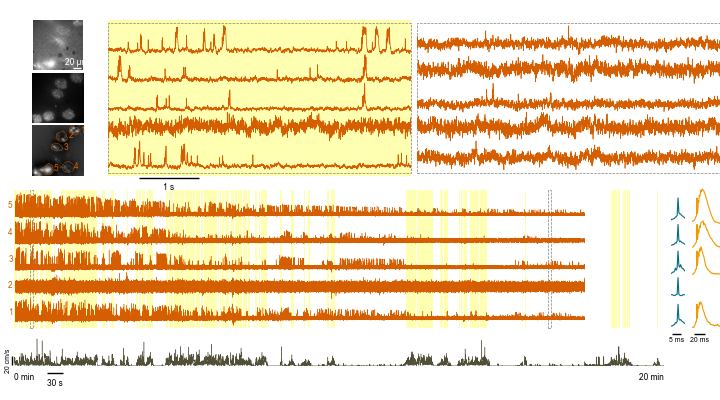

In [13]:
# Version 5: spike shapes with simple spikes (teal) and complex bursts (orange) overlaid
# Same as v4 but with SS/CS spike shape separation

# Define zoom windows for subplots 4 and 5
zoom_window = 5  # seconds
zoom1_start = 29.11  # seconds
zoom2_start = 984  # seconds

# Movement epoch parameters
speed_threshold = 3  # cm/s
min_duration_s = 0.25
merge_gap_s = 1
kernel_size = 51

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
from utils.GRC_helpers import _compute_moving_epochs

# Set global font to Arial
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 6
plt.rcParams['svg.fonttype'] = 'none'

# Single color for all cells
trace_color = '#D55E00'

# Create figure
fig = plt.figure(figsize=(7.2, 4))

# Create GridSpec: 2 rows for main layout
gs = gridspec.GridSpec(2, 16, height_ratios=[1.5, 2], width_ratios=[1]*14 + [0.35, 0.7], hspace=0.05, wspace=0.2)

# Create nested GridSpec for the 3 stacked images (in top-left area)
gs_images = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[0, 0:2], hspace=0.05)
ax1 = fig.add_subplot(gs_images[0])  # WF_image (top)
ax2 = fig.add_subplot(gs_images[1])  # mean_image1 (middle)
ax3 = fig.add_subplot(gs_images[2])  # mean_image2 (bottom)

# Top row trace subplots - use nested GridSpec to ensure equal width
gs_traces_top = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[0, 2:16], wspace=0.02)
ax4 = fig.add_subplot(gs_traces_top[0, 0])  # zoomed traces 1 (left half)
ax5 = fig.add_subplot(gs_traces_top[0, 1])  # zoomed traces 2 (right half)

# Bottom row subplot
ax6 = fig.add_subplot(gs[1, :14])    # traces (full width)
ax7_ss = fig.add_subplot(gs[1, 14])  # simple spike shapes (narrow)
ax7_cb = fig.add_subplot(gs[1, 15], sharey=ax7_ss)  # complex burst shapes (wider)

# Compute moving epochs
speed_smooth, moving_epochs, moving_idx = _compute_moving_epochs(
    speed, frame_rate,
    kernel_size=kernel_size, filter_type="boxcar",
    speed_threshold=speed_threshold,
    min_duration_s=min_duration_s, merge_gap_s=merge_gap_s
)

# Get weights and ROIs from first session
weights = weights_all[0]
ROIs = ROIs_all[0]

# Compute cell bounding boxes for labeling
cell_bounds = []
for cell_idx, roi in enumerate(ROIs):
    if np.nansum(roi) > 0:
        nonzero = np.where(roi > 0)
        y_min, y_max = nonzero[0].min(), nonzero[0].max()
        x_min, x_max = nonzero[1].min(), nonzero[1].max()
        cell_bounds.append({
            'cell_id': cell_idx + 1, 
            'y_min': y_min, 'y_max': y_max,
            'x_min': x_min, 'x_max': x_max
        })

num_cells = traces.shape[0]

# Plot images
vmin = np.percentile(WF_image, 0)
vmax = np.percentile(WF_image, 99.5)
ax1.imshow(WF_image, cmap='gray', aspect='equal', vmin=vmin, vmax=vmax)
ax1.axis('off')

# Add scale bar to WF image
pixel_size_um = 0.59 * 2
scale_bar_um = 20
scale_bar_pixels = scale_bar_um / pixel_size_um

wf_height, wf_width = WF_image.shape[:2]
scale_x_start = wf_width * 0.8
scale_y = wf_height * 0.95
ax1.plot([scale_x_start, scale_x_start + scale_bar_pixels], [scale_y, scale_y], 
         color='white', linewidth=1, solid_capstyle='butt')
ax1.text(scale_x_start + scale_bar_pixels/2, scale_y - wf_height*0.02, '20 μm', 
         fontsize=6, ha='center', va='bottom', color='white')

# Plot mean_image1 without overlay
ax2.imshow(mean_image1, cmap='gray', aspect='equal')
ax2.axis('off')

# Plot mean_image2 in grayscale and add ROI contours
ax3.imshow(mean_image2, cmap='gray', aspect='equal')
ax3.axis('off')

# Plot ROI contours (single color)
for i, roi in enumerate(ROIs):
    ax3.contour(roi, levels=[0.5], colors=[trace_color], linewidths=0.25)

# Add cell number labels (single color)
for cell_info in cell_bounds:
    text_x = cell_info['x_max'] + 2
    text_y = (cell_info['y_min'] + cell_info['y_max']) // 2
    ax3.text(text_x, text_y, str(cell_info['cell_id']), fontsize=6, color=trace_color,
             ha='left', va='center', fontweight='normal')

# Normalize traces for plotting
norm_traces = []
for i in range(num_cells):
    trace = traces[i].squeeze().copy()
    trace[:1000] = np.nan
    vmin = np.nanmin(trace)
    vmax = np.nanmax(trace)
    if vmax - vmin > 0:
        trace_norm = (trace - vmin) / (vmax - vmin)
    else:
        trace_norm = trace - vmin
    norm_traces.append(trace_norm)

time_axis = np.arange(traces.shape[1]) / sampling_rate
zoom1_end = zoom1_start + zoom_window

# Add movement epoch patches to zoomed subplot 4
for start, end in moving_epochs:
    t_start = start / frame_rate
    t_end = end / frame_rate
    if t_end >= zoom1_start and t_start <= zoom1_end:
        ax4.axvspan(max(t_start, zoom1_start), min(t_end, zoom1_end), 
                    color='yellow', alpha=0.3, zorder=0)

# Plot zoomed traces in subplot 4 (single color)
zoom1_idx_start = int(zoom1_start * sampling_rate)
zoom1_idx_end = int(zoom1_end * sampling_rate)
for i in range(num_cells):
    trace = traces[i].squeeze().copy()
    trace[:1000] = np.nan
    segment = trace[zoom1_idx_start:zoom1_idx_end]
    seg_min = np.nanmin(segment)
    seg_max = np.nanmax(segment)
    if np.isnan(seg_min) or np.isnan(seg_max) or (seg_max == seg_min):
        trace_norm = np.full_like(trace, np.nan)
    else:
        trace_norm = (trace - seg_min) / (seg_max - seg_min)
    ax4.plot(time_axis, trace_norm + i, linewidth=0.5, color=trace_color, rasterized=True)
ax4.set_xlim(zoom1_start, zoom1_end)
ax4.set_ylim(-0.2, num_cells + 0.2)
ax4.axis('off')

# 1-second scale bar for zoomed traces
scale_bar_1s = 1
scale_x_start_4 = zoom1_start + 0.5
scale_y_4 = -0.3
ax4.plot([scale_x_start_4, scale_x_start_4 + scale_bar_1s], [scale_y_4, scale_y_4], 
         color='black', linewidth=1, solid_capstyle='butt', clip_on=False)
ax4.text(scale_x_start_4 + scale_bar_1s / 2, scale_y_4 - 0.15, '1 s', 
         fontsize=6, ha='center', va='top')

# Add movement epoch patches to zoomed subplot 5
zoom2_end = zoom2_start + zoom_window
for start, end in moving_epochs:
    t_start = start / frame_rate
    t_end = end / frame_rate
    if t_end >= zoom2_start and t_start <= zoom2_end:
        ax5.axvspan(max(t_start, zoom2_start), min(t_end, zoom2_end), 
                    color='yellow', alpha=0.3, zorder=0)

# Plot zoomed traces in subplot 5 (single color)
zoom2_idx_start = int(zoom2_start * sampling_rate)
zoom2_idx_end = int(zoom2_end * sampling_rate)
for i in range(num_cells):
    trace = traces[i].squeeze().copy()
    trace[:1000] = np.nan
    segment = trace[zoom2_idx_start:zoom2_idx_end]
    seg_min = np.nanmin(segment)
    seg_max = np.nanmax(segment)
    if np.isnan(seg_min) or np.isnan(seg_max) or (seg_max == seg_min):
        trace_norm = np.full_like(trace, np.nan)
    else:
        trace_norm = (trace - seg_min) / (seg_max - seg_min)
    ax5.plot(time_axis, trace_norm + i, linewidth=0.5, color=trace_color, rasterized=True)
ax5.set_xlim(zoom2_start, zoom2_end)
ax5.set_ylim(-0.2, num_cells + 0.2)
ax5.axis('off')

# Add dashed box around traces in ax4
box_y_min_zoom = -0.1
box_y_max_zoom = num_cells + 0.1
box_height_zoom = box_y_max_zoom - box_y_min_zoom

rect_ax4 = Rectangle((zoom1_start, box_y_min_zoom), zoom_window, box_height_zoom,
                      linewidth=0.5, edgecolor='gray', facecolor='none',
                      linestyle='--', clip_on=False)
ax4.add_patch(rect_ax4)

# Add dashed box around traces in ax5
rect_ax5 = Rectangle((zoom2_start, box_y_min_zoom), zoom_window, box_height_zoom,
                      linewidth=0.5, edgecolor='gray', facecolor='none',
                      linestyle='--', clip_on=False)
ax5.add_patch(rect_ax5)

# Define bounding box limits for movement patches
box_y_min = -0.1
box_y_max = num_cells + 0.1
box_height = box_y_max - box_y_min

# Add movement epoch patches to bottom row (ax6)
for start, end in moving_epochs:
    t_start = start / frame_rate
    t_end = end / frame_rate
    epoch_rect = Rectangle((t_start, box_y_min), t_end - t_start, box_height,
                            facecolor='yellow', alpha=0.3, edgecolor='none', zorder=0)
    ax6.add_patch(epoch_rect)

# Plot traces in bottom row (ax6) - single color
for i in range(num_cells):
    ax6.plot(time_axis, norm_traces[i] + i, linewidth=0.3, color=trace_color, rasterized=True)
    ax6.text(time_axis[0]-3, i + 0.5, f'{i+1}', fontsize=6, ha='right', va='center', color=trace_color)

# Add speed trace at the bottom
speed_time = np.arange(len(speed_smooth)) / frame_rate
speed_max = np.nanmax(speed_smooth)
speed_normalized = speed_smooth / speed_max
speed_y_offset = -1.5

ax6.plot(speed_time, speed_normalized + speed_y_offset, linewidth=0.3, color="#524F38", rasterized=True)

# Add vertical scale bar for speed
speed_scale_value = 20  # cm/s
speed_scale_height = speed_scale_value / speed_max
vscale_x = time_axis[0] - 5
vscale_y_bottom = speed_y_offset
vscale_y_top = speed_y_offset + speed_scale_height
ax6.plot([vscale_x, vscale_x], [vscale_y_bottom, vscale_y_top], 
         color='black', linewidth=1, solid_capstyle='butt', clip_on=False)

ax6.text(vscale_x - 2, (vscale_y_bottom + vscale_y_top) / 2, f'{speed_scale_value} cm/s', 
         fontsize=5, ha='right', va='center', rotation=90, color='black')
ax6.axis('off')

# Calculate time range
time_range = time_axis[-1] - time_axis[0]

# Label start and end time in minutes
start_time_min = int(round(time_axis[0] / 60))
end_time_min = int(round(time_axis[-1] / 60))
ax6.text(time_axis[0], speed_y_offset - 0.3, f'{start_time_min} min', fontsize=6, ha='left', va='top')
ax6.text(time_axis[-1], speed_y_offset - 0.3, f'{end_time_min} min', fontsize=6, ha='right', va='top')

# Add horizontal scale bar (30 seconds)
scale_bar_length = 30
x_scale_start = time_axis[0] + time_range * 0.05
x_scale_end = x_scale_start + scale_bar_length
y_scale = speed_y_offset - 0.3

ax6.plot([x_scale_start, x_scale_end], [y_scale, y_scale], 
         color='black', linewidth=1, solid_capstyle='butt', clip_on=False)
ax6.text((x_scale_start + x_scale_end) / 2, y_scale - 0.2, '30 s', 
         fontsize=6, ha='center', va='top')

# Adjust limits
ax6.set_xlim(time_axis[0], time_axis[-1])
ax6.set_ylim(speed_y_offset - 1, num_cells + 0.3)

# ============ VERSION 5: Spike-shape with SS/CS side by side ============
# Simple spikes: 10 ms before and after
# Complex bursts: 10 ms before and 100 ms after
baseline_points = 3
waveform_scale = 0.8
waveform_linewidth = 0.8
min_spikes_for_plot = 5  # minimum number of spikes/bursts to plot

# Colors for simple spikes and complex bursts
complex_color = '#EE9B00'  # orange for complex bursts
simple_color = '#026C80'   # teal for simple spikes

# Time windows (in ms)
ss_pre_ms = 15
ss_post_ms = 15
cb_pre_ms = 20
cb_post_ms = 100

# Convert to samples
ss_pre_samp = int(round(ss_pre_ms * sampling_rate / 1000))
ss_post_samp = int(round(ss_post_ms * sampling_rate / 1000))
cb_pre_samp = int(round(cb_pre_ms * sampling_rate / 1000))
cb_post_samp = int(round(cb_post_ms * sampling_rate / 1000))

def _get_simple_spike_indices(cell_idx):
    """Get simple spike indices from refined_SS"""
    if refined_SS is None or cell_idx >= len(refined_SS):
        return np.array([], dtype=int)
    ss = refined_SS[cell_idx]
    if ss is None:
        return np.array([], dtype=int)
    return np.asarray(ss, dtype=int)

def _get_burst_first_spike_indices(cell_idx):
    """Get first spike of each complex burst from complex_bursts_dicts"""
    if complex_bursts_dicts is None or cell_idx >= len(complex_bursts_dicts):
        return np.array([], dtype=int)
    bursts = complex_bursts_dicts[cell_idx]
    if bursts is None:
        return np.array([], dtype=int)
    starts = np.asarray(bursts.get('starts', []), dtype=int)
    ends = np.asarray(bursts.get('ends', []), dtype=int)
    if len(starts) == 0:
        return np.array([], dtype=int)
    # Get CS spikes for this cell
    if all_CS_spikes is None or cell_idx >= len(all_CS_spikes):
        return np.array([], dtype=int)
    cs_spikes = np.asarray(all_CS_spikes[cell_idx], dtype=int)
    if cs_spikes.size == 0:
        return np.array([], dtype=int)
    # For each burst, get the first spike
    burst_first_spikes = []
    for start_idx, end_idx in zip(starts, ends):
        in_burst = cs_spikes[(cs_spikes >= start_idx) & (cs_spikes <= end_idx)]
        if in_burst.size > 0:
            burst_first_spikes.append(in_burst[0])
    return np.asarray(burst_first_spikes, dtype=int)

def _mean_spike_shape_v5(trace, spike_idx, pre_samp, post_samp):
    """Compute mean spike shape from spike indices with specified window"""
    if spike_idx.size == 0:
        return None, 0
    spike_idx = np.sort(spike_idx)
    shapes = []
    for t in spike_idx:
        if t - pre_samp < 0 or t + post_samp >= len(trace):
            continue
        segment = trace[t - pre_samp:t + post_samp + 1]
        if np.any(np.isnan(segment)):
            continue
        base_start = max(0, t - baseline_points)
        baseline = np.min(trace[base_start:t]) if t > base_start else trace[t]
        peak = trace[t]
        height = peak - baseline
        if not np.isfinite(height) or height <= 0:
            continue
        shapes.append((segment - baseline) / height)
    if not shapes:
        return None, 0
    return np.mean(np.stack(shapes, axis=0), axis=0), len(shapes)

# Setup simple spike shapes axis (ax7_ss)
ax7_ss.set_xlim(-ss_pre_ms, ss_post_ms)
ax7_ss.set_ylim(speed_y_offset - 1, num_cells + 0.3)
ax7_ss.axis('off')

# Setup complex burst shapes axis (ax7_cb)
ax7_cb.set_xlim(-cb_pre_ms, cb_post_ms)
ax7_cb.set_ylim(speed_y_offset - 1, num_cells + 0.3)
ax7_cb.axis('off')

# Time axes for waveforms
ss_waveform_t = np.linspace(-ss_pre_ms, ss_post_ms, ss_pre_samp + ss_post_samp + 1)
cb_waveform_t = np.linspace(-cb_pre_ms, cb_post_ms, cb_pre_samp + cb_post_samp + 1)

for i in range(num_cells):
    trace = traces[i].squeeze()
    
    # Get simple spike shape
    ss_idx = _get_simple_spike_indices(i)
    ss_shape, ss_count = _mean_spike_shape_v5(trace, ss_idx, ss_pre_samp, ss_post_samp)
    
    # Get complex burst shape (first spike of each burst)
    cb_idx = _get_burst_first_spike_indices(i)
    cb_shape, cb_count = _mean_spike_shape_v5(trace, cb_idx, cb_pre_samp, cb_post_samp)
    
    # Plot simple spikes if enough spikes
    if ss_shape is not None and ss_count >= min_spikes_for_plot:
        ax7_ss.plot(ss_waveform_t, ss_shape * waveform_scale + i, color=simple_color, 
                    linewidth=waveform_linewidth)
    
    # Plot complex bursts if enough bursts
    if cb_shape is not None and cb_count >= min_spikes_for_plot:
        ax7_cb.plot(cb_waveform_t, cb_shape * waveform_scale + i, color=complex_color, 
                    linewidth=waveform_linewidth)

# Scale bar for simple spikes (5 ms)
ss_scale_bar_ms = 20
ss_bar_x_start = -ss_pre_ms + 1
ss_bar_x_end = ss_bar_x_start + ss_scale_bar_ms
bar_y = -0.3
ax7_ss.plot([ss_bar_x_start, ss_bar_x_end], [bar_y, bar_y], color='black', linewidth=1, solid_capstyle='butt', clip_on=False)
ax7_ss.text((ss_bar_x_start + ss_bar_x_end) / 2, bar_y - 0.15, '5 ms', fontsize=5, ha='center', va='top')

# Scale bar for complex bursts (20 ms)
cb_scale_bar_ms = 50
cb_bar_x_start = -cb_pre_ms + 5
cb_bar_x_end = cb_bar_x_start + cb_scale_bar_ms
ax7_cb.plot([cb_bar_x_start, cb_bar_x_end], [bar_y, bar_y], color='black', linewidth=1, solid_capstyle='butt', clip_on=False)
ax7_cb.text((cb_bar_x_start + cb_bar_x_end) / 2, bar_y - 0.15, '20 ms', fontsize=5, ha='center', va='top')

# Box for zoom region 1
rect1 = Rectangle((zoom1_start, box_y_min), zoom_window, box_height,
                   linewidth=0.5, edgecolor='gray', facecolor='none',
                   linestyle='--', clip_on=False)
ax6.add_patch(rect1)

# Box for zoom region 2
rect2 = Rectangle((zoom2_start, box_y_min), zoom_window, box_height,
                   linewidth=0.5, edgecolor='gray', facecolor='none',
                   linestyle='--', clip_on=False)
ax6.add_patch(rect2)

output_figure_path = os.path.join(main_data_folder, 'neural_data_summary_figure_v5.svg')

plt.subplots_adjust(left=0.02, right=1.0, top=0.95, bottom=0.02)

fig.savefig(output_figure_path, dpi=300)

print(f"Figure saved to {os.path.abspath(output_figure_path)}")

In [ ]:
t1 = 130
t2 = 132
cell_idx = 2  # 0 based

complex_color = '#EE9B00'  # orange for complex bursts
simple_color = '#026C80'   # teal for simple spikes

# Create figure with single axis
fig, ax = plt.subplots(figsize=(2.8, 1.))

sampling_rate = 500
time_axis = np.arange(traces.shape[1]) / sampling_rate

# Get trace (no normalization)
trace = traces_SNR_interpolated[cell_idx].squeeze().copy()
trace[:1000] = np.nan

zoom_idx_start = int(t1 * sampling_rate)
zoom_idx_end = int(t2 * sampling_rate)

# Get Vm (no normalization)
vm = Vm_SNR_interpolated[cell_idx].squeeze().copy()
vm[:1000] = np.nan

# Use same color palette as the distinct-color figure
num_cells = traces.shape[0]
if num_cells <= 10:
    colors = plt.cm.tab10(np.linspace(0, 1, num_cells))
elif num_cells <= 20:
    colors = plt.cm.tab20(np.linspace(0, 1, num_cells))
else:
    colors = plt.cm.hsv(np.linspace(0, 1, num_cells, endpoint=False))


# Plot Vm in light gray (behind)
ax.plot(time_axis, vm, linewidth=1, color='gray', zorder=2)

# Plot trace in cell's distinct color (on top)
ax.plot(time_axis, trace, linewidth=0.5, color=trace_color, zorder=1)

# Get simple spikes and complex spikes for this cell
ss_indices = refined_SS[cell_idx] if refined_SS[cell_idx] is not None else []
cs_indices = all_CS_spikes[cell_idx] if all_CS_spikes[cell_idx] is not None else []

# Convert to arrays
ss_indices = np.asarray(ss_indices, dtype=int) if len(ss_indices) > 0 else np.array([], dtype=int)
cs_indices = np.asarray(cs_indices, dtype=int) if len(cs_indices) > 0 else np.array([], dtype=int)

# Filter spikes within zoom window
ss_in_window = ss_indices[(ss_indices >= zoom_idx_start) & (ss_indices < zoom_idx_end)]
cs_in_window = cs_indices[(cs_indices >= zoom_idx_start) & (cs_indices < zoom_idx_end)]

# Convert to time
ss_times = ss_in_window / sampling_rate
cs_times = cs_in_window / sampling_rate

# Compute y limits from data in zoom window
trace_segment = trace[zoom_idx_start:zoom_idx_end]
vm_segment = vm[zoom_idx_start:zoom_idx_end]
y_min = np.nanmin([np.nanmin(trace_segment), np.nanmin(vm_segment)])
y_max = np.nanmax([np.nanmax(trace_segment), np.nanmax(vm_segment)])
y_range = y_max - y_min
y_pad = 0.1 * y_range

# Plot rasters on top of trace
raster_y_bottom = y_max + 0.05 * y_range
raster_y_top = y_max + 0.15 * y_range

# Simple spikes
for t in ss_times:
    ax.plot([t, t], [raster_y_bottom, raster_y_top], color=simple_color, linewidth=0.5, zorder=3)

# Complex spikes
for t in cs_times:
    ax.plot([t, t], [raster_y_bottom, raster_y_top], color=complex_color, linewidth=0.5, zorder=3)

# Set limits and remove axes
ax.set_xlim(t1, t2)
ax.set_ylim(y_min - y_pad, raster_y_top + 0.05 * y_range)
ax.axis('off')

# Add horizontal scale bar (100 ms)
scale_bar_100ms = 0.1
scale_x_start = t1 + 0.02
scale_x_end = scale_x_start + scale_bar_100ms
scale_y = y_min - 0.5 * y_pad
ax.plot([scale_x_start, scale_x_end], [scale_y, scale_y], 
        color='black', linewidth=1., solid_capstyle='butt', clip_on=False)
ax.text((scale_x_start + scale_x_end) / 2, scale_y - 0.3 * y_pad, '100 ms', 
        fontsize=5, ha='center', va='top')

# Add vertical scale bar (length 1 = 1 spike height)
vscale_x = t1 + 0.02
vscale_y_bottom = scale_y
vscale_y_top = scale_y + 1
ax.plot([vscale_x, vscale_x], np.array([vscale_y_bottom, vscale_y_top])+0.9, 
        color='black', linewidth=1., solid_capstyle='butt', clip_on=False)
ax.text(vscale_x - 0.01, (vscale_y_bottom + vscale_y_top) / 2 + 0.9, '1 spk.\nheight', 
        fontsize=5, ha='right', va='center')

plt.tight_layout()
plt.subplots_adjust(left=0.0, right=1.0, top=1, bottom=0)

# Save figure
output_figure_path = os.path.join(main_data_folder, f'trace_with_spikes_cell{cell_idx+1}.svg')
fig.savefig(output_figure_path, dpi=300)
print(f'Saved: {output_figure_path}')
print(f'SS in window: {len(ss_in_window)}, CS in window: {len(cs_in_window)}')